In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

plt.style.use("ggplot")

In [4]:
matches=pd.read_csv("matches.csv")
deliveries=pd.read_csv("deliveries.csv")
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [5]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [6]:
matches.loc[matches['win_by_runs'].idxmax()]

id                               44
season                         2017
city                          Delhi
date                     2017-05-06
team1                Mumbai Indians
team2              Delhi Daredevils
toss_winner        Delhi Daredevils
toss_decision                 field
result                       normal
dl_applied                        0
winner               Mumbai Indians
win_by_runs                     146
win_by_wickets                    0
player_of_match         LMP Simmons
venue              Feroz Shah Kotla
umpire1                 Nitin Menon
umpire2                   CK Nandan
umpire3                         NaN
Name: 43, dtype: object

This match was won by the highest margin of runs in IPL history. showing complete dominance by the wining team.

In [7]:
matches.loc[matches['win_by_wickets'].idxmax()]

id                                                      3
season                                               2017
city                                               Rajkot
date                                           2017-04-07
team1                                       Gujarat Lions
team2                               Kolkata Knight Riders
toss_winner                         Kolkata Knight Riders
toss_decision                                       field
result                                             normal
dl_applied                                              0
winner                              Kolkata Knight Riders
win_by_runs                                             0
win_by_wickets                                         10
player_of_match                                   CA Lynn
venue              Saurashtra Cricket Association Stadium
umpire1                                       Nitin Menon
umpire2                                         CK Nandan
umpire3       

This match recorded the highest wicket-based victory indicating a strong chasing performance.

In [9]:
matches[matches['win_by_runs']>0].sort_values('win_by_runs').head(1)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
755,11415,2019,Hyderabad,12/05/19,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Mumbai Indians,1,0,JJ Bumrah,Rajiv Gandhi Intl. Cricket Stadium,Nitin Menon,Ian Gould,Nigel Llong


This match recorded by the smallest margin of runs reflecting a closely faught contest.

In [10]:
matches[matches['win_by_wickets']>0].sort_values('win_by_wickets').head(1)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
642,7900,2018,Hyderabad,12/04/18,Mumbai Indians,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,1,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",O Nandan,Nigel Llong,Vineet Kulkarni


This match was won by the minimum wicket margin showing pressure till the last moment.

In [11]:
matches['dl_applied'].value_counts()

dl_applied
0    737
1     19
Name: count, dtype: int64

Most IPL matches were played without D/L method,
while only a small number required D/L due to rain interruptions.

In [14]:
city_matches = matches['city'].value_counts()
city_matches

city
Mumbai            101
Kolkata            77
Delhi              74
Bangalore          66
Hyderabad          64
Chennai            57
Jaipur             47
Chandigarh         46
Pune               38
Durban             15
Bengaluru          14
Visakhapatnam      13
Centurion          12
Ahmedabad          12
Rajkot             10
Mohali             10
Indore              9
Dharamsala          9
Johannesburg        8
Cuttack             7
Ranchi              7
Port Elizabeth      7
Cape Town           7
Abu Dhabi           7
Sharjah             6
Raipur              6
Kochi               5
Kanpur              4
Nagpur              3
Kimberley           3
East London         3
Bloemfontein        2
Name: count, dtype: int64

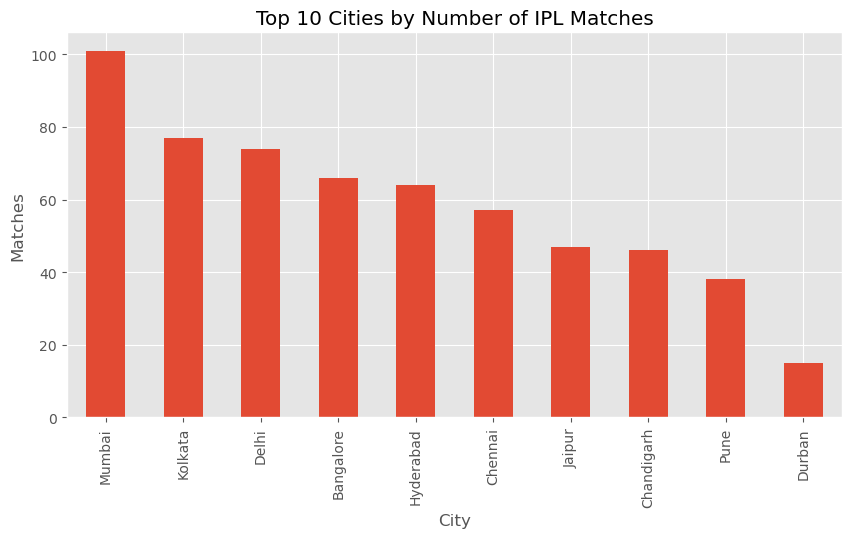

In [15]:
city_matches.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Cities by Number of IPL Matches")
plt.xlabel("City")
plt.ylabel("Matches")
plt.show()

Cities like Mumbai, Bangalore, and Kolkata have hosted the highest number of IPL matches, indicating strong cricket infrastructure and audience demand.

In [17]:
matches['winner'].value_counts()

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

Teams with consistent performance across seasons have higher win counts, reflecting strong team balance and leadership

In [18]:
matches['season'].value_counts().sort_index()

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
Name: count, dtype: int64

The number of matches per season increased over time, showing IPL’s growth and expansion.

In [19]:
matches['player_of_match'].value_counts().head(10)

player_of_match
CH Gayle          21
AB de Villiers    20
RG Sharma         17
MS Dhoni          17
DA Warner         17
YK Pathan         16
SR Watson         15
SK Raina          14
G Gambhir         13
MEK Hussey        12
Name: count, dtype: int64

A few star players dominate Man of the Match awards, highlighting their consistent match-winning impact.

In [21]:
(matches['toss_winner'] == matches['winner']).value_counts()

True     393
False    363
Name: count, dtype: int64

Winning the toss does not guarantee winning the match, indicating that on-field performance matters more than toss advantage.

In [22]:
matches['toss_decision'].value_counts()

toss_decision
field    463
bat      293
Name: count, dtype: int64

Captains prefer chasing over batting first, especially in high-pressure matches.

In [23]:
dl_season = matches[matches['dl_applied'] == 1]['season'].value_counts().sort_index()
dl_season

season
2008    2
2009    3
2011    3
2014    1
2015    2
2016    4
2017    1
2018    3
Name: count, dtype: int64

The use of the D/L method varies by season and depends on weather conditions, showing irregular but unavoidable interruptions in IPL matches.

In [24]:
matches['result'].value_counts()

result
normal       743
tie            9
no result      4
Name: count, dtype: int64

Most matches ended with normal results, while ties and no-results were comparatively rare.

In [25]:
matches['toss_winner'].value_counts()

toss_winner
Mumbai Indians                 98
Kolkata Knight Riders          92
Chennai Super Kings            89
Royal Challengers Bangalore    81
Kings XI Punjab                81
Delhi Daredevils               80
Rajasthan Royals               80
Sunrisers Hyderabad            46
Deccan Chargers                43
Pune Warriors                  20
Gujarat Lions                  15
Delhi Capitals                 10
Kochi Tuskers Kerala            8
Rising Pune Supergiants         7
Rising Pune Supergiant          6
Name: count, dtype: int64

Teams that frequently win the toss often make strategic decisions based on pitch and weather conditions.

In [26]:
venue_defend = matches.groupby('venue')['win_by_runs'].sum().sort_values(ascending=False)
venue_chase = matches.groupby('venue')['win_by_wickets'].sum().sort_values(ascending=False)

venue_defend.head()
venue_chase.head()

venue
Eden Gardens                                 275
M Chinnaswamy Stadium                        253
Wankhede Stadium                             216
Rajiv Gandhi International Stadium, Uppal    206
Feroz Shah Kotla                             206
Name: win_by_wickets, dtype: int64

Some venues favor teams defending totals, while others are more suitable for successful chases, indicating pitch behavior differences.

In [27]:
team_performance = matches.groupby('winner')[['win_by_runs', 'win_by_wickets']].sum()
team_performance

,win_by_runs,win_by_wickets
winner,,
Chennai Super Kings,1778,289
Deccan Chargers,421,72
Delhi Capitals,92,29
Delhi Daredevils,675,275
Gujarat Lions,1,65
Kings XI Punjab,925,268
Kochi Tuskers Kerala,23,30
Kolkata Knight Riders,1086,351
Mumbai Indians,1866,307


Certain teams excel at defending targets, while others are more successful during chases, reflecting their team composition and strategy.

In [28]:
matches['venue'].value_counts()

venue
Eden Gardens                                            77
M Chinnaswamy Stadium                                   73
Wankhede Stadium                                        73
Feroz Shah Kotla                                        67
Rajiv Gandhi International Stadium, Uppal               56
MA Chidambaram Stadium, Chepauk                         49
Sawai Mansingh Stadium                                  47
Punjab Cricket Association Stadium, Mohali              35
Maharashtra Cricket Association Stadium                 21
Subrata Roy Sahara Stadium                              17
Dr DY Patil Sports Academy                              17
Kingsmead                                               15
Punjab Cricket Association IS Bindra Stadium, Mohali    14
SuperSport Park                                         12
Sardar Patel Stadium, Motera                            12
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium     11
Brabourne Stadium                                 

Popular stadiums host a larger number of matches, indicating their importance in the IPL ecosystem.